# 🗳️ Morrow County Voter Dashboard
Interactive dashboard showing voter registration data by party and precinct

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [2]:
# Load the most recent parquet file
# Get the project root (parent of dashboard folder)
try:
    project_root = Path.cwd().parent if 'dashboard' in str(Path.cwd()) else Path.cwd()
    processed_dir = project_root / 'data' / 'processed'

    print(f'Looking for data in: {processed_dir}')
    print(f'Folder exists: {processed_dir.exists()}')

    if not processed_dir.exists():
        raise FileNotFoundError(f'Data directory does not exist: {processed_dir}')

    parquet_files = list(processed_dir.glob('**/voter_data.parquet'))

    if parquet_files:
        df = pd.read_parquet(parquet_files[0])
        if df.empty:
            raise ValueError('Parquet file is empty')
        print(f'✅ Loaded {len(df):,} voter records from parquet')
        print(f'Last updated: {df["LOAD_DATE"].max() if "LOAD_DATE" in df.columns else "Unknown"}')
    else:
        # Fallback to most recent CSV in data/processed
        csv_files = sorted(processed_dir.glob('voter_data_*.csv'), reverse=True)
        if csv_files:
            csv_file = csv_files[0]
            df = pd.read_csv(csv_file)
            if df.empty:
                raise ValueError('CSV file is empty')
            print(f'✅ Loaded {len(df):,} voter records from {csv_file.name}')
        else:
            raise FileNotFoundError(f'No voter data found in {processed_dir}')

except FileNotFoundError as e:
    print(f'❌ File Error: {e}')
    df = None
except ValueError as e:
    print(f'❌ Data Error: {e}')
    df = None
except Exception as e:
    print(f'❌ Unexpected error loading data: {e}')
    df = None

Looking for data in: d:\MCDP_PYTHONCODE\data\processed
Folder exists: True
✅ Loaded 23,996 voter records from parquet
Last updated: 2026-02-21 23:24:05.498948


## 📊 Key Metrics

In [3]:
if df is not None:
    total_voters = len(df)
    party_counts = df['PARTY_AFFILIATION'].value_counts()
    
    democrats = party_counts.get('Democrat', 0)
    republicans = party_counts.get('Republican', 0)
    unaffiliated = party_counts.get('Unaffiliated', 0)
    
    print('='*60)
    print('MORROW COUNTY VOTER REGISTRATION SUMMARY')
    print('='*60)
    print(f'Total Registered Voters: {total_voters:>20,}')
    print('-'*60)
    print(f'Democrats:               {democrats:>20,} ({democrats/total_voters*100:>5.1f}%)')
    print(f'Republicans:             {republicans:>20,} ({republicans/total_voters*100:>5.1f}%)')
    print(f'Unaffiliated:            {unaffiliated:>20,} ({unaffiliated/total_voters*100:>5.1f}%)')
    print('='*60)

MORROW COUNTY VOTER REGISTRATION SUMMARY
Total Registered Voters:               23,996
------------------------------------------------------------
Democrats:                              1,226 (  5.1%)
Republicans:                            7,844 ( 32.7%)
Unaffiliated:                          14,926 ( 62.2%)


## 👥 Party Affiliation Breakdown

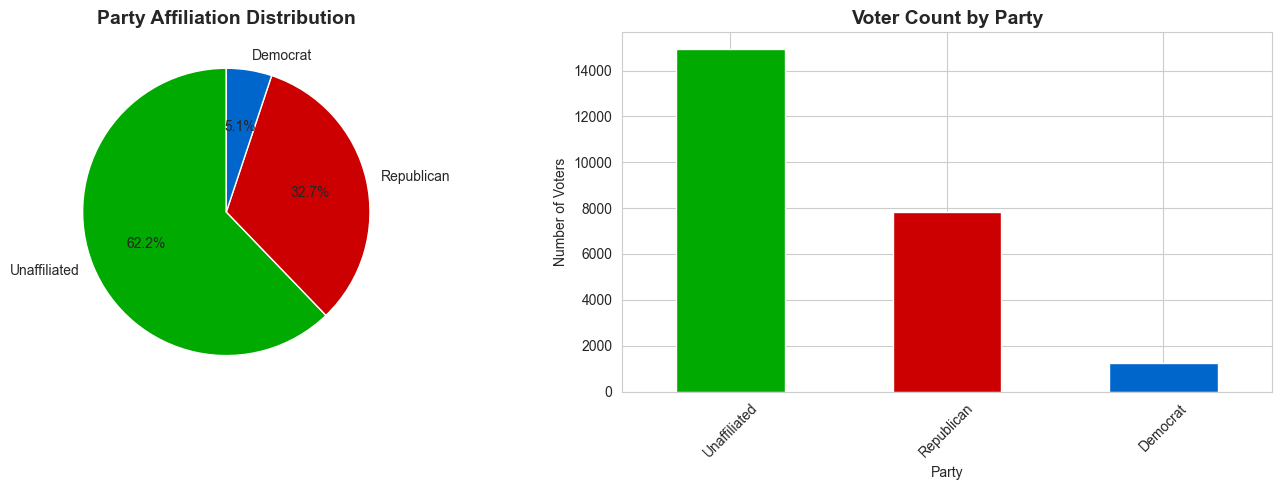

In [4]:
# Create party summary
# Define party colors: Blue for Democrat, Red for Republican, Green for Unaffiliated
party_colors = {
    'Democrat': '#0066CC',      # Blue
    'Republican': '#CC0000',    # Red
    'Unaffiliated': '#00AA00'   # Green
}

party_counts = None

if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    party_counts = df['PARTY_AFFILIATION'].value_counts()

    if party_counts is not None:
        # Map colors based on party names
        colors = [party_colors.get(party, '#808080') for party in party_counts.index]
        party_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('Party Affiliation Distribution', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('')

    # Bar chart
    if party_counts is not None:
        party_counts.plot(kind='bar', ax=axes[1], color=colors)
    axes[1].set_title('Voter Count by Party', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Party')
    axes[1].set_ylabel('Number of Voters')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print('❌ No data loaded - cannot create party breakdown chart')

## 📍 Precinct Analysis

In [5]:
# Party affiliation by precinct
if df is not None:
    precinct_party = df.groupby(['PRECINCT_NAME', 'PARTY_AFFILIATION']).size().unstack(fill_value=0)
    precinct_party['Total'] = precinct_party.sum(axis=1)
    precinct_party = precinct_party.sort_values('Total', ascending=False)

    print('\nVoter Count by Precinct and Party:')
    print(precinct_party.to_string())
else:
    print('❌ No data loaded - cannot create precinct analysis')
    precinct_party = None


Voter Count by Precinct and Party:
PARTY_AFFILIATION     Democrat  Republican  Unaffiliated  Total
PRECINCT_NAME                                                  
CONGRESS TWP WEST           82         375           823   1280
BENNINGTON TWP WEST         56         357           780   1193
HARMONY TWP S               45         323           759   1127
PERU TWP                    60         354           680   1094
BENNINGTON TWP EAST         58         370           660   1088
FRANKLIN TWP                51         400           636   1087
CONGRESS TWP EAST           45         376           442    863
WASHINGTON TWP              43         275           540    858
WESTFIELD TWP               60         284           512    856
TROY TWP                    49         269           484    802
LINCOLN TWP W               32         225           537    794
HARMONY TWP N               40         262           467    769
CARDINGTON TWP              47         287           431    765
N BL

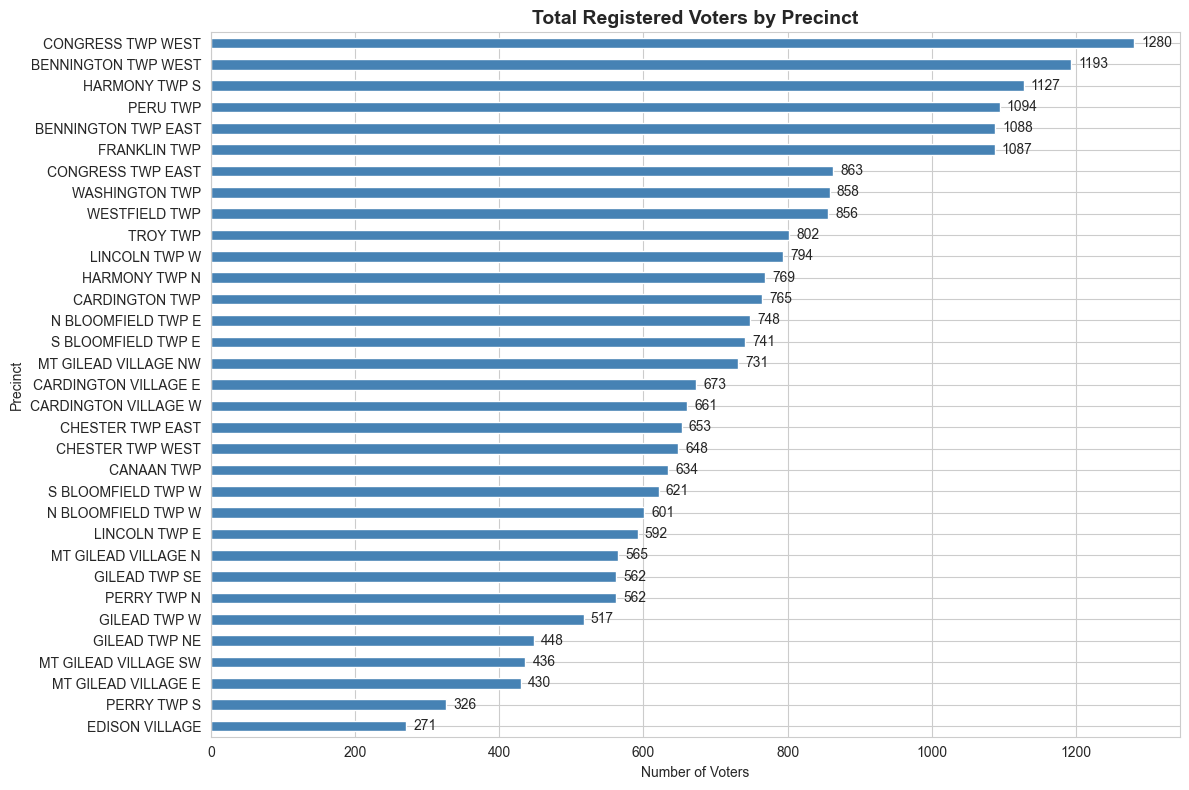

In [6]:
# Visualization 1: Total voters per precinct
if 'precinct_party' in dir() and precinct_party is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    precinct_party['Total'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Total Registered Voters by Precinct', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Precinct')

    # Add value labels
    for i, v in enumerate(precinct_party['Total'].sort_values().values):
        ax.text(v + 10, i, str(v), va='center')

    plt.tight_layout()
    plt.show()
else:
    print('❌ Precinct data not available - run previous cell first')

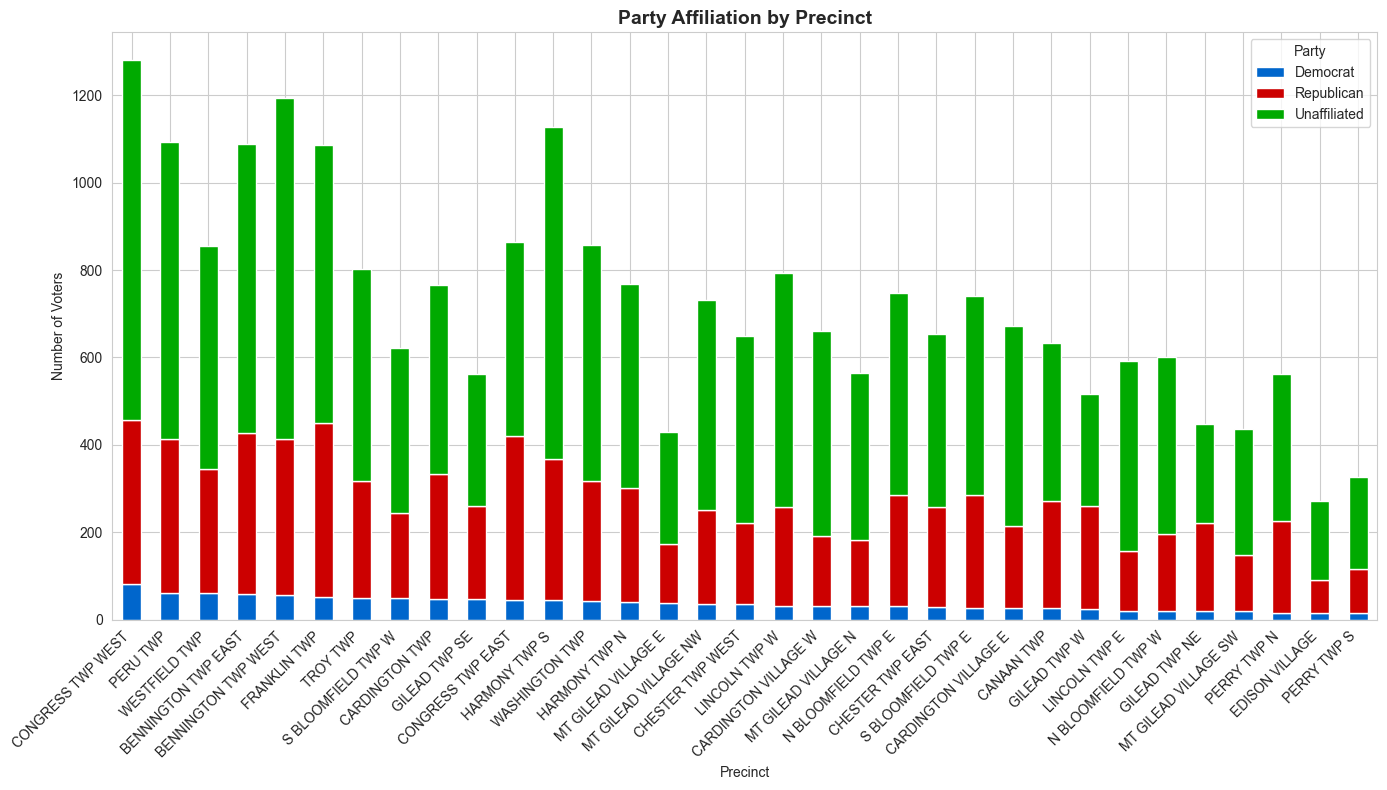

In [7]:
# Visualization 2: Stacked bar chart by party and precinct
if 'precinct_party' in dir() and precinct_party is not None and 'party_colors' in dir():
    fig, ax = plt.subplots(figsize=(14, 8))

    # Get party columns (exclude Total)
    party_cols = [col for col in precinct_party.columns if col != 'Total']
    precinct_party_sorted = precinct_party[party_cols].sort_values(by=party_cols[0], ascending=False)

    # Map colors based on party names
    colors = [party_colors.get(party, '#808080') for party in party_cols]
    precinct_party_sorted.plot(kind='bar', stacked=True, ax=ax, color=colors)
    ax.set_title('Party Affiliation by Precinct', fontsize=14, fontweight='bold')
    ax.set_xlabel('Precinct')
    ax.set_ylabel('Number of Voters')
    ax.legend(title='Party', loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Required data not available - run Cell 8 and Cell 10 first')

## 📋 Detailed Precinct Breakdown

In [8]:
# Display detailed breakdown for each precinct
if df is not None:
    for precinct in sorted(df['PRECINCT_NAME'].unique()):
        precinct_data = df[df['PRECINCT_NAME'] == precinct]
        precinct_parties = precinct_data['PARTY_AFFILIATION'].value_counts()
        
        print(f"\n{precinct}:")
        print(f"  Total: {len(precinct_data):>5,} voters")
        for party, count in precinct_parties.items():
            pct = count / len(precinct_data) * 100
            print(f"  - {party:15s}: {count:>5,} ({pct:>5.1f}%)")
else:
    print('❌ No data loaded - cannot display precinct breakdown')


BENNINGTON TWP EAST:
  Total: 1,088 voters
  - Unaffiliated   :   660 ( 60.7%)
  - Republican     :   370 ( 34.0%)
  - Democrat       :    58 (  5.3%)

BENNINGTON TWP WEST:
  Total: 1,193 voters
  - Unaffiliated   :   780 ( 65.4%)
  - Republican     :   357 ( 29.9%)
  - Democrat       :    56 (  4.7%)

CANAAN TWP:
  Total:   634 voters
  - Unaffiliated   :   362 ( 57.1%)
  - Republican     :   246 ( 38.8%)
  - Democrat       :    26 (  4.1%)

CARDINGTON TWP:
  Total:   765 voters
  - Unaffiliated   :   431 ( 56.3%)
  - Republican     :   287 ( 37.5%)
  - Democrat       :    47 (  6.1%)

CARDINGTON VILLAGE E:
  Total:   673 voters
  - Unaffiliated   :   459 ( 68.2%)
  - Republican     :   188 ( 27.9%)
  - Democrat       :    26 (  3.9%)

CARDINGTON VILLAGE W:
  Total:   661 voters
  - Unaffiliated   :   469 ( 71.0%)
  - Republican     :   160 ( 24.2%)
  - Democrat       :    32 (  4.8%)

CHESTER TWP EAST:
  Total:   653 voters
  - Unaffiliated   :   396 ( 60.6%)
  - Republican     :   

## 📈 Voter Status Analysis

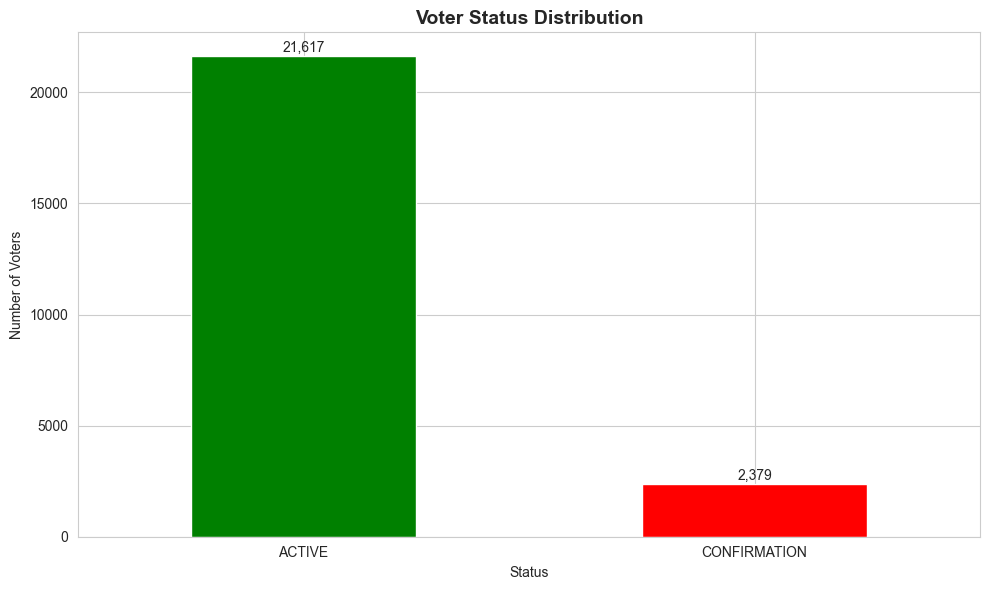


Voter Status Summary:
ACTIVE      :   21,617 ( 90.1%)
CONFIRMATION:    2,379 (  9.9%)


In [9]:
# Voter status breakdown
if df is not None and 'VOTER_STATUS' in df.columns:
    status_counts = df['VOTER_STATUS'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    status_counts.plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title('Voter Status Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Status')
    ax.set_ylabel('Number of Voters')
    ax.tick_params(axis='x', rotation=0)
    
    # Add value labels
    for i, v in enumerate(status_counts.values):
        ax.text(i, v + 50, str(f'{v:,}'), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print('\nVoter Status Summary:')
    for status, count in status_counts.items():
        pct = count / len(df) * 100
        print(f'{status:12s}: {count:>8,} ({pct:>5.1f}%)')
elif df is None:
    print('❌ No data loaded - cannot analyze voter status')
else:
    print('❌ VOTER_STATUS column not found in data')

## 🔍 Filter & View Full Data

In [10]:
# Interactive filtering
# Modify the values below to filter the data

if df is not None:
    # Filter options
    selected_party = ['Democrat', 'Republican', 'Unaffiliated']  # Change to filter by party
    selected_precinct = None  # Set to specific precinct name to filter, or None for all
    selected_status = ['ACTIVE', 'INACTIVE']  # Filter by voter status

    # Apply filters
    filtered_df = df.copy()
    filtered_df = filtered_df[filtered_df['PARTY_AFFILIATION'].isin(selected_party)]
    if selected_precinct:
        filtered_df = filtered_df[filtered_df['PRECINCT_NAME'] == selected_precinct]
    filtered_df = filtered_df[filtered_df['VOTER_STATUS'].isin(selected_status)]

    print(f'\nShowing {len(filtered_df):,} of {len(df):,} voters')
    print('\nFirst 20 records:')
    display(filtered_df.head(20))
else:
    print('❌ No data loaded - cannot filter')


Showing 21,617 of 23,996 voters

First 20 records:


,SOS_VOTERID,LAST_NAME,FIRST_NAME,MIDDLE_NAME,DATE_OF_BIRTH,PARTY_AFFILIATION,VOTER_STATUS,RESIDENTIAL_ADDRESS1,RESIDENTIAL_SECONDARY_ADDR,RESIDENTIAL_CITY,...,VILLAGE,WARD,LOAD_DATE,EMAIL,CELL_PHONE,HOME_PHONE,FACEBOOK_PROFILE,PARTICIPATION,DO_NOT_CALL,DONATE
0,OH0026277228,ALDEN,ROBIN,KATHRYN,1992,Democrat,ACTIVE,4815 TWP RD 213,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
1,OH0026277231,MURPHY,EDWIN,MICHAEL,1991,Democrat,ACTIVE,4815 TWP RD 213,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
2,OH0018493889,FARLING,JACK,D,1953,Democrat,ACTIVE,345 TWP RD 209,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
3,OH0025494908,GAINES,SOPHIA,ROSE,1997,Democrat,ACTIVE,1575 TWP RD 220,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
4,OH0017893659,BAUGHMAN,CHRISTINA,RENEE,1977,Democrat,ACTIVE,5169 ST RT 229,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
5,OH0017897757,DAVISON,DEBORAH,L,1957,Democrat,ACTIVE,5559 TWP RD 213,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
6,OH0017897786,ELGIN,VICKI,A,1951,Democrat,ACTIVE,5657 CO RD 13,,CENTERBURG,...,,,2026-02-21 23:24:05.498948,,,,,,,
7,OH0024369573,GRIFFITH,SUZANNE,M,1964,Democrat,ACTIVE,834 TWP RD 208,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
8,OH0025103167,ROGERS,BRENDA,LYN,1972,Democrat,ACTIVE,5151 CO RD 15,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,
9,OH0025108746,KAISER,JESSICA,ANNE,1993,Democrat,ACTIVE,5559 TWP RD 213,,MARENGO,...,,,2026-02-21 23:24:05.498948,,,,,,,


## 📊 Export Summary

In [11]:
# Create summary report
if df is not None:
    total_voters = len(df)
    party_counts = df['PARTY_AFFILIATION'].value_counts()
    democrats = party_counts.get('Democrat', 0)
    republicans = party_counts.get('Republican', 0)
    unaffiliated = party_counts.get('Unaffiliated', 0)
    
    summary_data = {
        'Metric': [
            'Total Registered Voters',
            'Democrats',
            'Republicans', 
            'Unaffiliated',
            'Active Voters',
            'Inactive Voters',
            'Total Precincts',
            'Data Last Updated'
        ],
        'Value': [
            f'{total_voters:,}',
            f'{democrats:,}',
            f'{republicans:,}',
            f'{unaffiliated:,}',
            f'{len(df[df["VOTER_STATUS"] == "ACTIVE"]):,}',
            f'{len(df[df["VOTER_STATUS"] == "INACTIVE"]):,}',
            f'{df["PRECINCT_NAME"].nunique()}',
            str(df['LOAD_DATE'].max() if 'LOAD_DATE' in df.columns else 'Unknown')[:10]
        ]
    }

    summary_df = pd.DataFrame(summary_data)
    print('\nDATASET SUMMARY REPORT')
    print('='*50)
    print(summary_df.to_string(index=False))
    print('='*50)
else:
    print('❌ No data loaded - cannot create summary report')


DATASET SUMMARY REPORT
                 Metric      Value
Total Registered Voters     23,996
              Democrats      1,226
            Republicans      7,844
           Unaffiliated     14,926
          Active Voters     21,617
        Inactive Voters          0
        Total Precincts         33
      Data Last Updated 2026-02-21
